<center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/6/6f/Dauphine_logo_2019_-_Bleu.png" style="width: 600px;"/> 
</center>  

<div align="center"><span style="font-family:Arial Black;font-size:32px;color:darkblue">Python for finance</span></div>

# Optimisation de portefeuille

## Modèle Moyenne – Variance de Markowitz 

Au début des années 50, Harry Markowitz propose le critère d’analyse **moyenne – variance** et  dès lors il jette les bases de ce qui sera appelé plus tard la **Théorie moderne du portefeuille**. En effet, Markowitz part du principe que les rendements générés par un titre ou actif sont des variables aléatoires, ensuite <u> il propose les deux premiers moments à savoir la moyenne et la variance comme les critères de mesure respectifs de l’espérance et du risque perçus par un investisseur rationnel. </u>

L'optimisation d'un portefeuille consiste donc à chercher au sein d'un univers de titres donné, les valeurs et les proportions de valeurs permettant de constituer un portefeuille situé sur <u> **la frontière efficiente**</u>.

## Manipulation de titres

On commence par importer nos librairies habituelles

In [5]:
!pip3.11 install pandas numpy yfinance


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip


In [6]:
#on peut utiliser yfinance si pandareader marche pas
import pandas as pd
import numpy as np
import datetime

On installe un nouveau module qui permet de télécharger les données direcement depuis des beses de données internet comme FRED, Yahoo Finance, Quandl ou Google Finance

**pip** est l’outil d’installation de prédilection. À partir de Python 3.4, il est inclus par défaut avec l’installateur de Python. 

Il s'utilise directement sur l'invite de commandes, avec la syntaxe suivante
> **pip install** *SomePackage*

Pour utiliser des commandes "Shell", c'est à dire qui ont vocation à être utilisées dans un invite des commandes directement sur Jupyter, mettre un **point d'exclamation** au début de la cellule. 

> **! pip install** *SomePackage*

Nous allons donc installer **pandas_datareader** et en importer le module ".data" sous alias web

In [7]:
!pip3.11 install --upgrade yfinance


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip


Initialiser une valeur de stock, une date de fin et une date de début. 

In [8]:
import datetime
import yfinance as yf

# cours de bourse de Tesla qui a pour ticker "TSLA"
tesla = yf.Ticker("TSLA")

# on choisit un an entier, la performance sur un an étant souvent prioritaire quand on optimise un portefeuille
date_debut = datetime.datetime(2021, 1, 1)
date_fin = datetime.datetime(2024, 1, 1)

Ecrivez la requête pour obtenir un cours de bourse, par exemple SPY

In [9]:
# obtention des données historiques pour Tesla du 01/01/2021 au 01/01/2024
data = tesla.history(start=date_debut, end=date_fin, interval="1d")

Afficher les données 

In [10]:
# affichage des données
data
# la colonne date commence au 4 janvier car c'était le premier jour de bourse aux Etats-Unis en 2021

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00-05:00,239.820007,248.163330,239.063339,243.256668,145914600,0.0,0.0
2021-01-05 00:00:00-05:00,241.220001,246.946671,239.733337,245.036667,96735600,0.0,0.0
2021-01-06 00:00:00-05:00,252.830002,258.000000,249.699997,251.993332,134100000,0.0,0.0
2021-01-07 00:00:00-05:00,259.209991,272.329987,258.399994,272.013336,154496700,0.0,0.0
2021-01-08 00:00:00-05:00,285.333344,294.829987,279.463318,293.339996,225166500,0.0,0.0
...,...,...,...,...,...,...,...
2023-12-22 00:00:00-05:00,256.760010,258.220001,251.369995,252.539993,93370100,0.0,0.0
2023-12-26 00:00:00-05:00,254.490005,257.970001,252.910004,256.609985,86892400,0.0,0.0
2023-12-27 00:00:00-05:00,258.350006,263.339996,257.519989,261.440002,106494400,0.0,0.0


Récupération de la colonne contenant les prix de clôture

In [11]:
# récupération de la colonne "Close" car elle contient les prix de clôture
close_prices = data['Close']

Visusalisation des données 

In [12]:
# affichage de la colonne des prix de clôture
print(close_prices)

Date
2021-01-04 00:00:00-05:00    243.256668
2021-01-05 00:00:00-05:00    245.036667
2021-01-06 00:00:00-05:00    251.993332
2021-01-07 00:00:00-05:00    272.013336
2021-01-08 00:00:00-05:00    293.339996
                                ...    
2023-12-22 00:00:00-05:00    252.539993
2023-12-26 00:00:00-05:00    256.609985
2023-12-27 00:00:00-05:00    261.440002
2023-12-28 00:00:00-05:00    253.179993
2023-12-29 00:00:00-05:00    248.479996
Name: Close, Length: 753, dtype: float64


On s'assure que les dates sont bien triées 

In [13]:
# tri des données par les dates (d'où le index) dans l'ordre croissant
data_sorted = close_prices.sort_index()

# affichage des données triées qui s'avéraient être déjà triées au préalable
print(data_sorted)

Date
2021-01-04 00:00:00-05:00    243.256668
2021-01-05 00:00:00-05:00    245.036667
2021-01-06 00:00:00-05:00    251.993332
2021-01-07 00:00:00-05:00    272.013336
2021-01-08 00:00:00-05:00    293.339996
                                ...    
2023-12-22 00:00:00-05:00    252.539993
2023-12-26 00:00:00-05:00    256.609985
2023-12-27 00:00:00-05:00    261.440002
2023-12-28 00:00:00-05:00    253.179993
2023-12-29 00:00:00-05:00    248.479996
Name: Close, Length: 753, dtype: float64


### Calcul de la moyenne et de la volatilité empirique sur les rendements 

Calcul des rendements, du rendement moyen et de la volatilité moyenne

In [14]:
#on continue avec les prix à la clôture
# calcul des rendements journaliers à l'aide de la formule de variation en pourcentage des prix de clôture (prix_t - prix_t-1) / prix_t-1
data['Return'] = data['Close'].pct_change()

# calcul du rendement moyen qui est la moyenne des rendements journaliers ci-dessus
rendement_moyen = data['Return'].mean()

# calcul de la volatilité moyenne qui est l'écart-type des rendements journaliers ci-dessus
volatilite_moyenne = data['Return'].std()

# affichage des résultats
print(rendement_moyen)
print(volatilite_moyenne)

0.0007149459586574953
0.03709882422821309


Annualisation des résultats

In [15]:
# annualisation du rendement moyen sachant qu'il y a 252 jours boursiers par an aux US
rendement_annualise = rendement_moyen * 252

# annualisation de la volatilité moyenne, on doit multiplier par la racine carée du nombre de jours boursiers (252)
volatilite_annualisee = volatilite_moyenne * (252 ** 0.5)

# affichage des résultats
print(rendement_annualise)
print(volatilite_annualisee)

0.18016638158168882
0.5889255770444976


## CONSTRUCTION DU PORTEFEUILLE

On commence par récupérer les tickers des titres qui composent notre portefeuille

In [16]:
# nous avons choisi comme titres Tesla (TSLA), Apple (AAPL), Ford Motor Company (F), Starbucks (SBUX)
# liste des tickers des titres dans le portefeuille
tickers_portefeuille = ["TSLA", "AAPL", "F", "SBUX"]

On vérfie que la liste est bien triée par ordre alphabétique car cela est un prérequis pour pandas_datareader . Pour être sur, on force un tri. 

In [17]:
# trier la liste par ordre alphabétique
tickers_portefeuille.sort()

print(tickers_portefeuille)

['AAPL', 'F', 'SBUX', 'TSLA']


On télécharge à présent les prix journaliers de clôture pour nos titres sur la même période que la partie 1

In [18]:
# dictionnaire pour stocker les données des prix de clôture de chaque action
data_dict = {}

# boucle pour récupérer les données pour chaque ticker dans le portefeuille
for ticker in tickers_portefeuille:
    stock = yf.Ticker(ticker)
    data = stock.history(start=date_debut, end=date_fin, interval="1d")
    data_dict[ticker] = data['Close']  # récupère uniquement les prix de clôture

On visualise nos données, les 5 premières lignes suffisent

In [19]:
# créer un DataFrame à partir du dictionnaire
df_portefeuille = pd.DataFrame(data_dict)

# affichage du DataFrame
print("Tableau des prix de clôture pour chaque action dans le portefeuille :")
print(df_portefeuille.head())  # .head pour afficher les 5 premières lignes

Tableau des prix de clôture pour chaque action dans le portefeuille :
                                 AAPL         F       SBUX        TSLA
Date                                                                  
2021-01-04 00:00:00-05:00  125.856705  6.395298  91.530472  243.256668
2021-01-05 00:00:00-05:00  127.412781  6.492879  91.832344  245.036667
2021-01-06 00:00:00-05:00  123.123856  6.635498  92.498161  251.993332
2021-01-07 00:00:00-05:00  127.325203  6.800635  91.752434  272.013336
2021-01-08 00:00:00-05:00  128.424210  6.755596  93.812096  293.339996


On vérifie que l'indice est bien trié

In [20]:
# triage de l'indice avec boucle qui parcourt les titres
for ticker, data in data_dict.items():
    data_dict[ticker] = data.sort_index()
    print(ticker)
    print(data_dict[ticker].head()) # affiche les 5 premières lignes
    print(data_dict[ticker].tail()) # affiche les 5 dernières lignes pour montrer que c'est trié
    print("\n")  # séparation entre les affichages

AAPL
Date
2021-01-04 00:00:00-05:00    125.856705
2021-01-05 00:00:00-05:00    127.412781
2021-01-06 00:00:00-05:00    123.123856
2021-01-07 00:00:00-05:00    127.325203
2021-01-08 00:00:00-05:00    128.424210
Name: Close, dtype: float64
Date
2023-12-22 00:00:00-05:00    191.609482
2023-12-26 00:00:00-05:00    191.065125
2023-12-27 00:00:00-05:00    191.164093
2023-12-28 00:00:00-05:00    191.589661
2023-12-29 00:00:00-05:00    190.550461
Name: Close, dtype: float64


F
Date
2021-01-04 00:00:00-05:00    6.395298
2021-01-05 00:00:00-05:00    6.492879
2021-01-06 00:00:00-05:00    6.635498
2021-01-07 00:00:00-05:00    6.800635
2021-01-08 00:00:00-05:00    6.755596
Name: Close, dtype: float64
Date
2023-12-22 00:00:00-05:00    10.630774
2023-12-26 00:00:00-05:00    10.716853
2023-12-27 00:00:00-05:00    10.665205
2023-12-28 00:00:00-05:00    10.622165
2023-12-29 00:00:00-05:00    10.493046
Name: Close, dtype: float64


SBUX
Date
2021-01-04 00:00:00-05:00    91.530472
2021-01-05 00:00:00-05:

On calcule les rendements, ainsi que le rendement moyen et la matrice de variance-covariance. 

In [21]:
# calcul des rendements journaliers
rendements_dict = {}
for ticker, data in data_dict.items():
    rendements_dict[ticker] = data.pct_change()

# conversion en DataFrame
rendements_df = pd.DataFrame(rendements_dict)

# suppression des NaN, les valeurs vides
rendements_df = rendements_df.dropna()

# calcul du rendement moyen
rendement_moyen = rendements_df.mean()

# calcul de la matrice de variance-covariance
matrice_var_cov = rendements_df.cov()

# affichage des résultats
print("Rendements journaliers :")
print(rendements_df.head(), "\n")

print("Rendement moyen :")
print(rendement_moyen, "\n")

print("Matrice de variance-covariance :")
print(matrice_var_cov, "\n")

Rendements journaliers :
                               AAPL         F      SBUX      TSLA
Date                                                             
2021-01-05 00:00:00-05:00  0.012364  0.015258  0.003298  0.007317
2021-01-06 00:00:00-05:00 -0.033662  0.021965  0.007250  0.028390
2021-01-07 00:00:00-05:00  0.034123  0.024887 -0.008062  0.079447
2021-01-08 00:00:00-05:00  0.008631 -0.006623  0.022448  0.078403
2021-01-11 00:00:00-05:00 -0.023249  0.033333 -0.010126 -0.078214 

Rendement moyen :
AAPL    0.000705
F       0.001017
SBUX    0.000137
TSLA    0.000715
dtype: float64 

Matrice de variance-covariance :
          AAPL         F      SBUX      TSLA
AAPL  0.000307  0.000179  0.000149  0.000354
F     0.000179  0.000717  0.000182  0.000377
SBUX  0.000149  0.000182  0.000303  0.000227
TSLA  0.000354  0.000377  0.000227  0.001376 



## Création de la frontière d'efficience

#### Définiton 
La frontière efficiente désigne le point où, pour un niveau donné de risque prévisible, **il n'existe pas d’autre combinaison d'actifs** délivrant un rendement potentiel plus important et où, pour un niveau donné de rendements prévisible, il n'existe aucune autre combinaison d'actifs affichant un risque prévu plus faible.
Pour tracer la frontière efficiente, il est nécessaire de calculer la totalité des combinaisons possibles entre les différentes classes d’actif et de ne garder que les combinaisons optimales.
Ces combinaisons optimales sont celles qui, pour un écart type donné, fournissent le meilleur rendement attendu supérieur.
Symétriquement, ce sont aussi celles qui, pour rendement donné, offre le risque attendu le plus bas possible.
Dans un espace à 2 dimensions (risque et rendement attendu), ces combinaisons optimales permettent de dessiner une courbe.

#### Rappel de cours : Ratio de Sharpe

**Le ratio de Sharpe** permet de mesurer la **rentabilité** d’un portefeuille en fonction du **risque** pris.

C'est le quotient de l’excès de rentabilité par rapport au taux sans risque divisé par le risque total du portefeuille. 

En d’autres termes, il permet de calculer la performance d’un investissement par rapport à celle d’un placement sans risque.

La formule nécessaire au calcul est donc : 

$$S_p={R_p-R_F \over\sigma_p}$$

**Avec:** 
$$S_p : \text{ Ratio de Sharpe du portefeuille risqué P}$$ 
$$R_p : \text{ Rendement du portefeuille risqué P}$$ 
$$R_F : \text{ Taux sans risque}$$ 
$$\sigma_P : \text{ Volatilité du portefeuille risqué P}$$ 

#### Application

Définissez un nombre de tirages de portefeuilles aléatoires 

In [22]:
# nombre de tirages de portefeuilles aléatoires, on choisit 15 000 pour être sûr de trouver le portefeuille optimal
nbr_portefeuilles = 15000

Création de la matrice de récupération des résultats

In [23]:
# on suppose un taux sans risque
taux_sans_risque = 0.02

# initialisation de la matrice pour stocker les résultats (4 lignes : rendement, risque, ratio de Sharpe, poids de tous les actifs)
resultats = np.zeros((len(tickers_portefeuille) + 3, nbr_portefeuilles))  # 3 + nombre d'actifs (car chaque actif aura son poids)

In [24]:
for i in range(nbr_portefeuilles):
    
    # on génère des poids aléatoires pour les actifs du portefeuille
    poids = np.random.random(len(tickers_portefeuille))  # on utilise random de numpy pour des poids aléatoire
    poids /= np.sum(poids)  # vérification que la somme des poids soit égale à 1
    
    # calcul du rendement moyen annualisé et de la volatilité moyenne annualisée
    rendement_portefeuille = np.sum(poids * rendements_df.mean()) * 252  # rendement annualisé (252 jours de bourse par an aux US)
    ecart_type_portefeuille = np.sqrt(np.dot(poids.T, np.dot(rendements_df.cov() * 252, poids)))  # volatilité annualisée
    
    # stockage des résultats dans la matrice
    resultats[0, i] = rendement_portefeuille  # rendement du portefeuille
    resultats[1, i] = ecart_type_portefeuille  # volatilité du portefeuille
    
    # calcul du ratio de Sharpe pour le portefeuille
    ratio_sharpe = (rendement_portefeuille - taux_sans_risque) / ecart_type_portefeuille
    resultats[2, i] = ratio_sharpe  # ratio de Sharpe du portefeuille
    
    # stockage des poids de chaque actif
    resultats[3:, i] = poids

On convertit notre matrice de résultat en DataFrame pour simplifier les traitements

In [25]:
# conversion des résultats en DataFrame
resultats_df = pd.DataFrame(resultats.T, columns=["Return", "Volatility", "Sharpe", *tickers_portefeuille])

On retrouve le portefeuille avec le plus grand ratio de Sharpe

In [26]:
# trouve l'indice du portefeuille avec le meilleur ratio de Sharpe
indice_max_sharpe = np.argmax(resultats[2])  # retourne l'indice

# récupère les résultats pour ce portefeuille
rendement_max_sharpe = resultats[0, indice_max_sharpe]  # rendement du portefeuille avec le meilleur ratio de Sharpe
vol_max_sharpe = resultats[1, indice_max_sharpe]  # volatilité
sharpe_max_sharpe = resultats[2, indice_max_sharpe]  # ratio de Sharpe

# récupère les poids de tous les actifs pour ce portefeuille
poids_max_sharpe = resultats[3:, indice_max_sharpe]

# affichage des résultats
print(f"Portefeuille avec le meilleur ratio de Sharpe:")
print(f"Rendement attendu: {rendement_max_sharpe:.4f}")
print(f"Volatilité (Risque): {vol_max_sharpe:.4f}")
print(f"Ratio de Sharpe: {sharpe_max_sharpe:.4f}")
print("Poids des actifs dans ce portefeuille :")
for i, ticker in enumerate(tickers_portefeuille):
    print(f"{ticker}: {poids_max_sharpe[i]:.4f}")

Portefeuille avec le meilleur ratio de Sharpe:
Rendement attendu: 0.2033
Volatilité (Risque): 0.2743
Ratio de Sharpe: 0.6684
Poids des actifs dans ce portefeuille :
AAPL: 0.6254
F: 0.3516
SBUX: 0.0139
TSLA: 0.0091


On retrouve le portefeuille avec la plus petite volatilité 

In [27]:
# trouve l'index du portefeuille avec la plus petite volatilité
indice_min_vol = np.argmin(resultats[1])  # retourne l'indice

# récupère les résultats pour ce portefeuille
rendement_min_vol = resultats[0, indice_min_vol]  # rendement du portefeuille avec la plus petite volatilité
ecart_type_min_vol = resultats[1, indice_min_vol]  # volatilité (risque) 
sharpe_min_vol = resultats[2, indice_min_vol]  # ratio de Sharpe

# récupère les poids de tous les actifs pour ce portefeuille
poids_min_vol = resultats[3:, indice_min_vol]

# affichage des résultats
print(f"Portefeuille avec la plus petite volatilité :")
print(f"Rendement attendu: {rendement_min_vol:.4f}")
print(f"Volatilité (Risque): {ecart_type_min_vol:.4f}")
print(f"Ratio de Sharpe: {sharpe_min_vol:.4f}")
print("Poids des actifs dans ce portefeuille :")
for i, ticker in enumerate(tickers_portefeuille):
    print(f"{ticker}: {poids_min_vol[i]:.4f}")

Portefeuille avec la plus petite volatilité :
Rendement attendu: 0.1196
Volatilité (Risque): 0.2373
Ratio de Sharpe: 0.4194
Poids des actifs dans ce portefeuille :
AAPL: 0.4816
F: 0.0719
SBUX: 0.4451
TSLA: 0.0013


###  Tracé de la frontière 

On commence par importer le module nécessaire

In [28]:
!pip3.11 install matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip


In [29]:
# import du module qui sert à faire des figures graphiques
import matplotlib.pyplot as plt

* Créer un scatter plot qui varie selon le ratio de Sharpe
* Tracer une étoile rouge pour marquer le portefeuille ayant le meilleur ratio de Sharpe> 
* Tracer une étoile verte pour marque le portefeuille de variance minimale

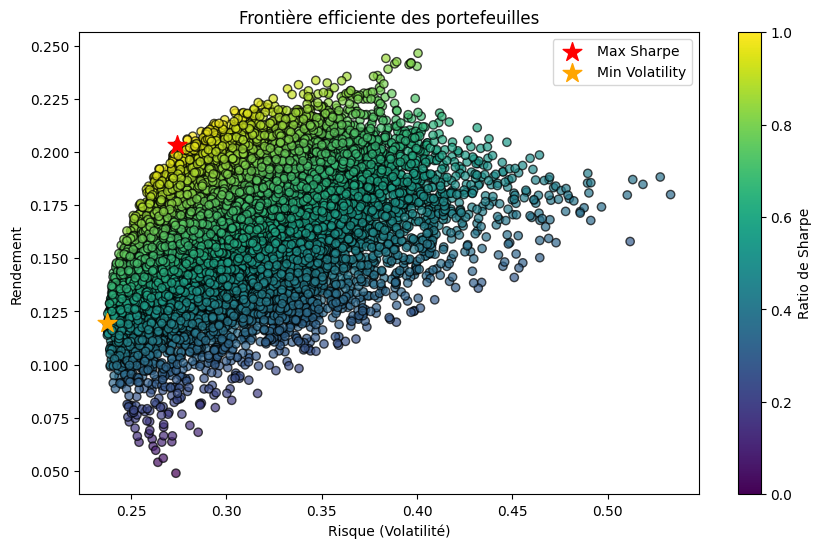

In [30]:
# traçage de la frontière efficiente
plt.figure(figsize=(10, 6))

# nuage de points (d'où le scatter pour scatter plot) des portefeuilles simulés, la couleur varie selon le ratio de Sharpe
plt.scatter(resultats[1], resultats[0], c=resultats[2], cmap="viridis", marker="o", edgecolors="k", alpha=0.7)

# tracer une étoile rouge pour le portefeuille ayant le meilleur ratio de Sharpe
plt.scatter(vol_max_sharpe, rendement_max_sharpe, c="red", marker="*", s=200, label="Max Sharpe")

# tracer une étoile verte pour le portefeuille de variance minimale
plt.scatter(ecart_type_min_vol, rendement_min_vol, c="orange", marker="*", s=200, label="Min Volatility")

plt.xlabel("Risque (Volatilité)") #label en abscisse
plt.ylabel("Rendement") # label en ordonnée
plt.title("Frontière efficiente des portefeuilles") #titre
plt.colorbar(label="Ratio de Sharpe") #titre de la légende couleur

plt.legend()
plt.show()